# **Evaluasi dan Peningkatan Model (Model Evaluation and Improvement)**
Catatan ini mengulas secara mendalam teknik evaluasi dan optimasi model machine learning pada ranah Supervised Learning. Fokus utama pembahasan meliputi pengukuran kapabilitas generalisasi model, optimasi hiperparameter, serta pemilihan metrik evaluasi yang selaras dengan tujuan penyelesaian masalah.Tujuan PembelajaranGeneralisasi Data: Memahami urgensi pemisahan dataset menjadi himpunan latih (training set) dan himpunan uji (test set).Validasi Silang: Menerapkan Cross-Validation untuk memperoleh estimasi performa yang lebih stabil dan representatif.Optimasi Parameter: Menggunakan Grid Search untuk mencari kombinasi parameter model terbaik tanpa memicu kebocoran data (data leakage).Pemilihan Metrik: Mengidentifikasi dan menerapkan metrik klasifikasi (Akurasi, Precision, Recall, F1-Score, ROC-AUC) serta metrik regresi (MAE, MSE, RMSE, $R^2$) secara tepat sasaran.

# **Bagian 1: Persiapan Lingkungan Kerja (Environment Setup)**
Modul ini menggunakan pustaka standar komputasi saintifik Python dan memuat dataset bawaan dari scikit-learn untuk menjamin reproduksibilitas kode.

In [35]:
# Memuat pustaka komputasi dan visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Memuat dataset sintetik dan bawaan
from sklearn.datasets import load_iris, load_breast_cancer, make_blobs, make_classification, make_regression

# Memuat modul untuk evaluasi dan optimasi model
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, StratifiedKFold,
    LeaveOneOut, ShuffleSplit, GroupKFold, GridSearchCV
)

# Memuat algoritma klasifikasi dan regresi
from sklearn.linear_model import LogisticRegression, Ridge, LinearRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Memuat metrik evaluasi
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_curve,
    roc_auc_score, mean_absolute_error, mean_squared_error, r2_score
)

# Konfigurasi parameter dasar
np.random.seed(42)
pd.set_option("display.max_columns", 100)

# **Bagian 2: Evaluasi Fundamental (Training Set dan Test Set)**
Dalam supervised learning, model tidak boleh dievaluasi menggunakan data yang sama dengan data latihnya. Hal ini akan menghasilkan estimasi yang sangat optimis namun bias (model menghafal data atau overfitting). Himpunan uji (test set) harus diisolasi sejak awal sebagai representasi data baru yang belum pernah dilihat oleh model.

In [36]:
# Simulasi Dataset dan Pembagian Train/Test
X, y = make_blobs(random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Pelatihan dan Evaluasi Baseline Model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

print(f"Skor Latih (Training Score): {logreg.score(X_train, y_train):.2f}")
print(f"Skor Uji (Test Score)      : {logreg.score(X_test, y_test):.2f}")

Skor Latih (Training Score): 0.91
Skor Uji (Test Score)      : 0.88


# **Bagian 3: Validasi Silang (Cross-Validation)**
Cross-validation adalah prosedur evaluasi yang membagi data menjadi beberapa lipatan (folds). Model dilatih dan divalidasi secara berulang menggunakan kombinasi lipatan yang berbeda. Hal ini menghasilkan evaluasi performa yang jauh lebih stabil dan tahan terhadap bias variansi pemisahan data dibandingkan metode train-test split tunggal.



---
## **Tabel Strategi Cross-Validation :**

|  | |
| :--- | :---: |
|Strategi | Karakteristik / Kondisi Penggunaan |
| KFold | Membagi data secara berurutan. Cocok untuk dataset regresi umum |
| StratifiedKFold | Menjaga proporsi distribusi kelas target. Wajib untuk klasifikasi. |
| LeaveOneOut (LOOCV) | 1 sampel menjadi himpunan uji per iterasi. Hanya untuk dataset sangat kecil. |
| ShuffleSplit | Memisahkan data secara acak dengan proporsi latih-uji yang fleksibel. |
| GroupKFold | Mencegah sampel dari kelompok yang sama terpisah ke himpunan latih dan uji.|


In [37]:
# 1. K-Fold Cross-Validation Standar pada Dataset Iris
iris = load_iris()
scores = cross_val_score(logreg, iris.data, iris.target, cv=5)
print(f"Skor CV Rata-rata: {scores.mean():.2f} (Standar Deviasi: {scores.std():.2f})")

# 2. Stratified K-Fold (Sangat direkomendasikan untuk klasifikasi)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_skf = cross_val_score(logreg, iris.data, iris.target, cv=skf)
print(f"Skor Stratified CV Rata-rata: {scores_skf.mean():.2f}")

# 3. Pengendalian Grup menggunakan GroupKFold
X_group, y_group = make_blobs(n_samples=12, random_state=0)
groups = np.array([0, 0, 0, 1, 1, 1, 1, 2, 2, 3, 3, 3]) # Indikator grup
group_kfold = GroupKFold(n_splits=3)
scores_group = cross_val_score(LogisticRegression(max_iter=1000), X_group, y_group, groups=groups, cv=group_kfold)
print(f"Skor GroupKFold Rata-rata: {scores_group.mean():.2f}")

Skor CV Rata-rata: 0.97 (Standar Deviasi: 0.02)
Skor Stratified CV Rata-rata: 0.97
Skor GroupKFold Rata-rata: 0.67


# **Bagian 4: Optimasi Hiperparameter dengan Grid Search**
Grid Search mengevaluasi seluruh kombinasi parameter yang didefinisikan untuk mencari konfigurasi model paling optimal. Kesalahan fatal yang umum terjadi adalah mengevaluasi parameter tersebut langsung pada Test Set. Pendekatan paling tangguh (dan benar secara metodologi) adalah mengombinasikan Grid Search dengan Cross-Validation (GridSearchCV) secara eksklusif pada Training Set, dan hanya menggunakan Test Set pada tahap final.

In [38]:
# Memisahkan himpunan latih dan uji
X_trainval, X_test, y_trainval, y_test = train_test_split(iris.data, iris.target, random_state=0)

# Definisi ruang pencarian parameter
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1, 10, 100]
}

# Inisialisasi GridSearchCV (terintegrasi dengan 5-fold CV)
grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_trainval, y_trainval)

print("Kombinasi Parameter Terbaik:", grid_search.best_params_)
print(f"Skor Validasi Silang Terbaik: {grid_search.best_score_:.2f}")
print(f"Skor Evaluasi Final (Test Set): {grid_search.score(X_test, y_test):.2f}")

Kombinasi Parameter Terbaik: {'C': 10, 'gamma': 0.1}
Skor Validasi Silang Terbaik: 0.97
Skor Evaluasi Final (Test Set): 0.97


# **Bagian 5: Metrik Evaluasi (Evaluation Metrics)**
Akurasi tidak selalu menjadi metrik yang komprehensif, khususnya pada dataset yang mengalami ketidakseimbangan kelas (Class Imbalance). Algoritma yang memprediksi kelas mayoritas secara membabi buta akan mendapatkan akurasi tinggi, namun gagal mengidentifikasi kelas minoritas yang justru seringkali menjadi fokus analitis utama (misal: deteksi penipuan atau diagnosis penyakit).

# **Metrik Klasifikasi :**

|Metrik  |Fokus Evaluasi | Rumus Konseptual|
| :--- | :---: | ---:|
|Precision | Menekan False Positive (Ketepatan Prediksi) | $\frac{TP}{TP + FP}$|
|Recall | Menekan False Negative (Sensitivitas/Kepekaan) | $\frac{TP}{TP + FN}$|
|F1-Score |Keseimbangan Harmonik Precision dan Recall|2 $\times \frac{Precision \times Recall}{Precision + Recall}$|

In [39]:
# Eksplorasi Metrik Klasifikasi Biner pada Dataset Kanker
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=42)

clf = LogisticRegression(max_iter=5000).fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Menampilkan Laporan Klasifikasi Lengkap
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

# Matriks Konfusi
cm_df = pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["Aktual Ganas (Malignant)", "Aktual Jinak (Benign)"],
    columns=["Prediksi Ganas", "Prediksi Jinak"]
)
display(cm_df)

              precision    recall  f1-score   support

   malignant       0.98      0.91      0.94        53
      benign       0.95      0.99      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



,Prediksi Ganas,Prediksi Jinak
Aktual Ganas (Malignant),48,5
Aktual Jinak (Benign),1,89


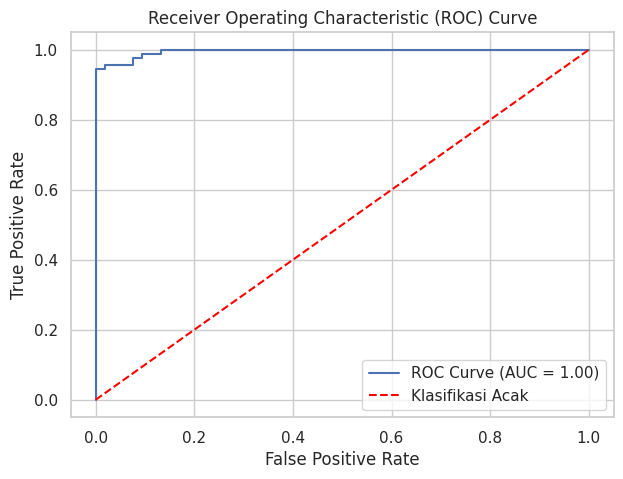

In [40]:
# Evaluasi menggunakan Kurva ROC dan Skor AUC
y_score = clf.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color='red', label="Klasifikasi Acak")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.show()

# **Metrik Regresi :**

|Metrik  |Karakteristik |
| :--- | :---: |
|MAE| Menghitung rata-rata selisih absolut. Interpretasi sejalan dengan satuan asal target.|
|MSE / RMSE	 | Memberikan penalti besar pada eror yang ekstrem (outliers). |
|$R^2$ Score |Mengukur seberapa baik model merepresentasikan variansi data (Maksimal 1.0).|

In [41]:
# Eksplorasi Metrik Regresi
X_reg, y_reg = make_regression(n_samples=300, n_features=5, noise=20, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, random_state=42)

reg = LinearRegression().fit(X_train_r, y_train_r)
y_pred_reg = reg.predict(X_test_r)

pd.DataFrame({
    "Metrik Evaluasi": ["MAE", "MSE", "RMSE", "R-Squared"],
    "Nilai": [
        mean_absolute_error(y_test_r, y_pred_reg),
        mean_squared_error(y_test_r, y_pred_reg),
        np.sqrt(mean_squared_error(y_test_r, y_pred_reg)),
        r2_score(y_test_r, y_pred_reg)
    ]
})

,Metrik Evaluasi,Nilai
0,MAE,14.719496
1,MSE,373.077744
2,RMSE,19.315221
3,R-Squared,0.968722


# **Kostumisasi Parameter Scoring**
Pustaka scikit-learn memungkinkan kita menentukan metrik optimasi secara spesifik (misalnya mengutamakan Recall) saat melakukan pencarian Grid Search.

In [42]:
# Grid Search dioptimalkan khusus untuk metrik Recall
param_grid_lr = {"C": [0.001, 0.01, 0.1, 1, 10, 100]}

grid_recall = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid_lr, cv=5, scoring="recall"
)
grid_recall.fit(X_train, y_train)

print("Parameter Terbaik Berdasarkan Recall:", grid_recall.best_params_)
print(f"Skor CV Recall Terbaik: {grid_recall.best_score_:.3f}")

Parameter Terbaik Berdasarkan Recall: {'C': 1}
Skor CV Recall Terbaik: 0.970
